In [35]:
import numpy as np
import pandas as pd
import os #Für Arbeit mit Dateipfaden
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [45]:
# Lädt einen dataframe mit pdb-IDs und zugehörigen CDR-Sequenzen. Keine doppelten oder NA Sequenzeinträge
regions = ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]
df = (
    pd.read_csv("data/ab_ag_annotated.tsv", sep="\t", usecols=["pdb"] + ["antigen_name"] + ["antigen_species"] + regions)
    .dropna(subset = regions)
    .drop_duplicates(subset = regions, keep='first')
    .reset_index(drop=True)
)

In [37]:
# Bereitet Tokenisierung und Embedding vor.
# Code wurde auf Tobis Rechner durchgeführt. Der Ordner 'embeddings' wurde anschließend in unserem Repo in 'data' eingefügt.
'''import torch #Für Arbeit mit neuronalen Netzen
from esm.models.esmc import ESMC
from esm.utils.constants.models import ESMC_600M
from esm.tokenization import EsmSequenceTokenizer
# EsmSequenceTokenizer ist eine Objektklasse, die Methoden wie .encode() und .decode() hat,
# um zwischen Sequenz und Aminosäure-Tokens zu unterscheiden
from esm.utils import encoding
# encoding ist ein Modul (.py-Datei), das Funktionen wie tokenize_sequence(seq=str, tokenizer=EsmSequenceTokenizer, ...) enthält

esm = ESMC.from_pretrained("esmc_600m").to('cuda')
# Lädt das trainierte (d.h. z.B. optimierte weights und biases durch Minimuerung der Loss-Function) ESMC-Modell mit dem Befehl, das Modell auf der GPU auszuführen
tokenizer = EsmSequenceTokenizer()
# Lädt den Tokenizer als Objekt einer Klasse mit Methoden wie .encode() und .decode(), um zwischen AS-Identität und zugehöriger Token-ID zu übersetzen'''

'import torch #Für Arbeit mit neuronalen Netzen\nfrom esm.models.esmc import ESMC\nfrom esm.utils.constants.models import ESMC_600M\nfrom esm.tokenization import EsmSequenceTokenizer\n# EsmSequenceTokenizer ist eine Objektklasse, die Methoden wie .encode() und .decode() hat,\n# um zwischen Sequenz und Aminosäure-Tokens zu unterscheiden\nfrom esm.utils import encoding\n# encoding ist ein Modul (.py-Datei), das Funktionen wie tokenize_sequence(seq=str, tokenizer=EsmSequenceTokenizer, ...) enthält\n\nesm = ESMC.from_pretrained("esmc_600m").to(\'cuda\')\n# Lädt das trainierte (d.h. z.B. optimierte weights und biases durch Minimuerung der Loss-Function) ESMC-Modell mit dem Befehl, das Modell auf der GPU auszuführen\ntokenizer = EsmSequenceTokenizer()\n# Lädt den Tokenizer als Objekt einer Klasse mit Methoden wie .encode() und .decode(), um zwischen AS-Identität und zugehöriger Token-ID zu übersetzen'

In [38]:
# Erstellt für jeden PDB-Eintrag einen Ordner, der die Embeddings aller CDR-Regionen als NumPy-Arrays enthält.
# Code wurde auf Tobis Rechner durchgeführt. Der Ordner 'embeddings' wurde anschließend in unserem Repo in 'data' eingefügt.
'''for region in regions:
    to_process = [
       (n, s)
       for n, s in zip(df.pdb, df[region])
    ]
    with torch.no_grad():
    # no_grad heißt: keine Backpropagation für Anpassung der weights und bias um loss-function zu minimieren (= Modell trainieren), sondern neuronales Netz nur "vorwärts" laufen lassen
        for name, seq in to_process:
            tokenized = encoding.tokenize_sequence(seq, tokenizer, add_special_tokens=True).to('cuda')
            # encoding: ein Modul aus dem Paket esm.utils
            # tokenize_sequence: Funktion aus dem Modul encoding: Wandelt AS-Sequenz (str) in das Input-Layer des neuralen Netzes um, indem es jeder AS-Identität (str) eine Token-ID (num) zuweist
            # add_special_tokens=True: fügt am Anfang und Ende der Token-Sequenz je ein Sondertoken ein, um Anfang und Ende für das Modell sichtbar zu machen
            pred = esm.forward(tokenized.unsqueeze(0))
            # tokenized.unsqueeze(0) fügt dem Input-Vektor tokenized eine zusätzliche Dimension hinzu, die der batch_size(= Anzahl der gleichzeitig untersuchten Proteine) entspricht.
            # tokenized wird formal zu einer Matrix, obwohl die zusätzliche Dimension leer ist, weil bei uns: batch_size = 1
            # --> tokenized.unsequeeze(0).shape = [Sequenzlänge, batch_size = 1]
            # notwendig, weil esm.forward() eine solche Matrix erwartet
            # esm.forward(): "schickt" die Input-Matrix durch das Transformer-Netzwerk (d.h. führt Matrix-Multiplikation mit den beim Training eingestellten weights und biases durch)
            # --> pred ist eine Matrix aus den logits des Output-Layers (Reihen entsprechen einzelnen AS in der Sequenzen, mehrere Spalten pro AS repräsentieren eine AS im Ouuput-Layer des Transformers)
            embeddings = pred.embeddings.to('cpu').squeeze()
            # pred.embeddings: prozessiert die Matrix (WIE?) und speichert sie als embeddings ab
            # .to('cpu'): embeddings wird wieder in der cpu gespeichert, da numpy hier arbeitet
            # .squeeze: .unsqueeze() wird wieder rückgängig gemacht
            embed_as_arr = embeddings.float().detach().numpy()
            # .float():Klassen der Einträge der Logits werden in floats umgewandelt. GPU hat vorher mit bfloat16 gearbeitet
            # .detach(): Informationen über das zugrungdeliegende Transformer-Netz wird verworfen, da wir nicht an Backpropagation interessiert sind
            # .numpy(): wandelt embeddings von der Klasse tensor aus PyTorch in ein array aus NumPy um
            embed_as_arr = embed_as_arr[1:-1,:]
            # Entfernt die SpecialTokens, die in der ersten Code-Zeile zugefügt wurden
            # --> entfernt erste und letzte Reihe des 2D-arrays, alle Spalten bleiben erhalten
            if not os.path.exists(f"esmc_ansatz/embeddings/{name}"):
                os.makedirs(f"esmc_ansatz/embeddings/{name}")
            np.save(f"esmc_ansatz/embeddings/{name}/{name}_{region}.npy", embed_as_arr)
            # Speichert das NumPy-Array ab'''

'for region in regions:\n    to_process = [\n       (n, s)\n       for n, s in zip(df.pdb, df[region])\n    ]\n    with torch.no_grad():\n    # no_grad heißt: keine Backpropagation für Anpassung der weights und bias um loss-function zu minimieren (= Modell trainieren), sondern neuronales Netz nur "vorwärts" laufen lassen\n        for name, seq in to_process:\n            tokenized = encoding.tokenize_sequence(seq, tokenizer, add_special_tokens=True).to(\'cuda\')\n            # encoding: ein Modul aus dem Paket esm.utils\n            # tokenize_sequence: Funktion aus dem Modul encoding: Wandelt AS-Sequenz (str) in das Input-Layer des neuralen Netzes um, indem es jeder AS-Identität (str) eine Token-ID (num) zuweist\n            # add_special_tokens=True: fügt am Anfang und Ende der Token-Sequenz je ein Sondertoken ein, um Anfang und Ende für das Modell sichtbar zu machen\n            pred = esm.forward(tokenized.unsqueeze(0))\n            # tokenized.unsqueeze(0) fügt dem Input-Vektor to

In [39]:
'''fs_rows = []
for region in regions:
    for i, df_row in df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        antigen_species = df_row["antigen_species"]
    
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"{i}" for i in range(embedding_as_vec.shape[0])])
    # Speichert die Embedding-Vektoren in einem DataFrame, der später für KMeans genutzt wird

    X = feature_space.drop(columns=["pdb"] + ["antigen_name"] + ["antigen_species"]).values
    X_2d = PCA(n_components=2).fit_transform(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=pd.Categorical(feature_space["antigen_name"]).codes, cmap='tab10', s=10)
    plt.title(f"Embeddings der {region}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    #labels = KMeans(n_clusters=10, random_state=42).fit_predict(X)'''



'fs_rows = []\nfor region in regions:\n    for i, df_row in df.iterrows():\n        pdb = df_row["pdb"]\n        antigen_name = df_row["antigen_name"]\n        antigen_species = df_row["antigen_species"]\n    \n        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")\n        #embedding_as_vec = embedding_as_arr.mean(axis=0)\n        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()\n\n        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()\n        fs_rows.append(fs_row)\n    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"{i}" for i in range(embedding_as_vec.shape[0])])\n    # Speichert die Embedding-Vektoren in einem DataFrame, der später für KMeans genutzt wird\n\n    X = feature_space.drop(columns=["pdb"] + ["antigen_name"] + ["antigen_species"]).values\n    X_2d = PCA(n_components=2).fit_transform(X)\n    plt.figure(figsize=(8, 6))\n    plt

C:\Users\marce\AppData\Local\Temp\ipykernel_8532\2175843337.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 162
  plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")


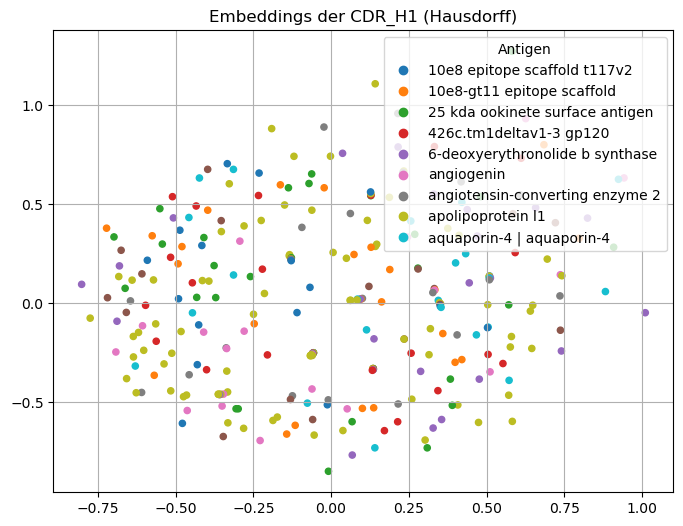

C:\Users\marce\AppData\Local\Temp\ipykernel_8532\2175843337.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 162
  plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")


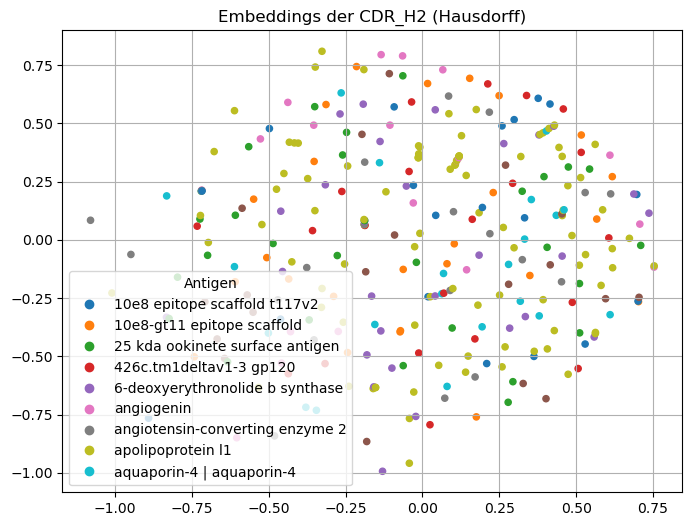

C:\Users\marce\AppData\Local\Temp\ipykernel_8532\2175843337.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 162
  plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")


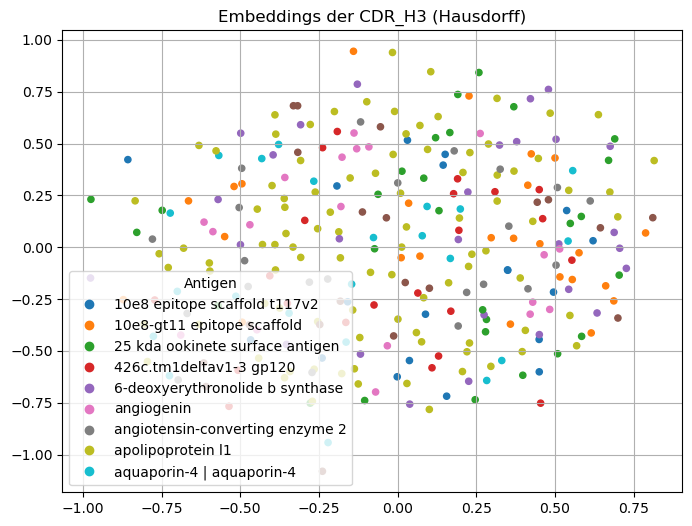

C:\Users\marce\AppData\Local\Temp\ipykernel_8532\2175843337.py:32: UserWarning: Mismatched number of handles and labels: len(handles) = 9 len(labels) = 162
  plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")


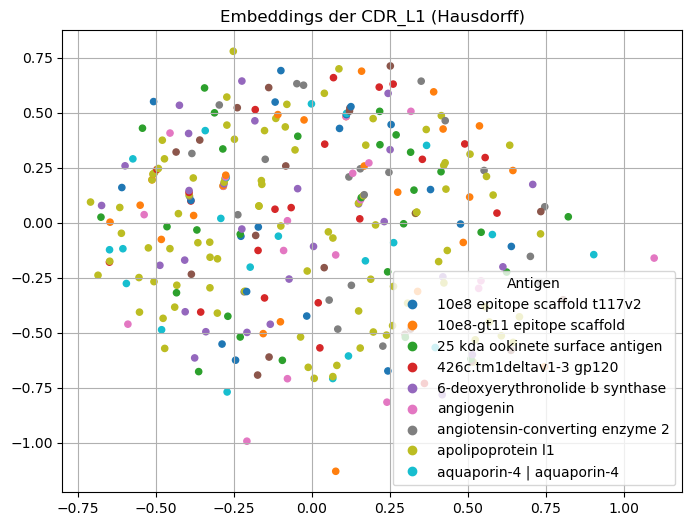

In [ ]:
# Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling
from scipy.spatial.distance import directed_hausdorff
from sklearn.manifold import MDS

subset_df = df.sample(300, random_state=42)


for region in regions:
    alle_embeddings = []
    labels = []
    for i, df_row in subset_df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        #antigen_species = df_row["antigen_species"]
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        alle_embeddings.append(embedding_as_arr)
        labels.append(antigen_name)
    n = len(alle_embeddings)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist_matrix)

    label_codes = pd.Categorical(labels).codes
    label_categories = pd.Categorical(labels).categories
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=label_codes, cmap='tab10', s=20)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")
    plt.title(f"Embeddings der {region} (Hausdorff)")
    plt.grid(True)
    plt.show()
    